# Multiclass obesity level prediction project

* The current project aimed to compare the performance of x with y in predicting obesity level.
* This dataset include data for the estimation of obesity levels in individuals based on their eating habits and physical condition.
* Classes: Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/donavanrooi/Documents/Data Science/Obesity Level/ObesityDataSet_raw_and_data_sinthetic.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [4]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [5]:
cat_features = df.drop(['Age', 'Height', 'Weight','FCVC','NCP','CH2O','FAF','TUE'], axis=1)

In [6]:
cat_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Gender                          2111 non-null   object
 1   family_history_with_overweight  2111 non-null   object
 2   FAVC                            2111 non-null   object
 3   CAEC                            2111 non-null   object
 4   SMOKE                           2111 non-null   object
 5   SCC                             2111 non-null   object
 6   CALC                            2111 non-null   object
 7   MTRANS                          2111 non-null   object
 8   NObeyesdad                      2111 non-null   object
dtypes: object(9)
memory usage: 148.6+ KB


In [7]:
num_features = df.drop(['Gender', 'family_history_with_overweight', 'FAVC','CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],axis=1)

In [8]:
num_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     2111 non-null   float64
 1   Height  2111 non-null   float64
 2   Weight  2111 non-null   float64
 3   FCVC    2111 non-null   float64
 4   NCP     2111 non-null   float64
 5   CH2O    2111 non-null   float64
 6   FAF     2111 non-null   float64
 7   TUE     2111 non-null   float64
dtypes: float64(8)
memory usage: 132.1 KB


# Data preprocessing

Label encoding the categorical features

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()

df_cat = cat_features.apply(le.fit_transform)

In [11]:
df_cat

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,0,1,0,2,0,0,3,3,1
1,0,1,0,2,1,1,2,3,1
2,1,1,0,2,0,0,1,3,1
3,1,0,0,2,0,0,1,4,5
4,1,0,0,2,0,0,2,3,6
...,...,...,...,...,...,...,...,...,...
2106,0,1,1,2,0,0,2,3,4
2107,0,1,1,2,0,0,2,3,4
2108,0,1,1,2,0,0,2,3,4
2109,0,1,1,2,0,0,2,3,4


Merging the categorial and numerical dataframes

In [12]:
final_df = pd.merge(num_features, df_cat, left_index=True, right_index=True)

In [13]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Height                          2111 non-null   float64
 2   Weight                          2111 non-null   float64
 3   FCVC                            2111 non-null   float64
 4   NCP                             2111 non-null   float64
 5   CH2O                            2111 non-null   float64
 6   FAF                             2111 non-null   float64
 7   TUE                             2111 non-null   float64
 8   Gender                          2111 non-null   int64  
 9   family_history_with_overweight  2111 non-null   int64  
 10  FAVC                            2111 non-null   int64  
 11  CAEC                            2111 non-null   int64  
 12  SMOKE                           21

# Exploratory Data Analysis


Performing value counts of obesity levels df['NObeyesdad'] using df['NObeyesdad'].valuecounts

In [14]:
value_counts = final_df["NObeyesdad"].value_counts()

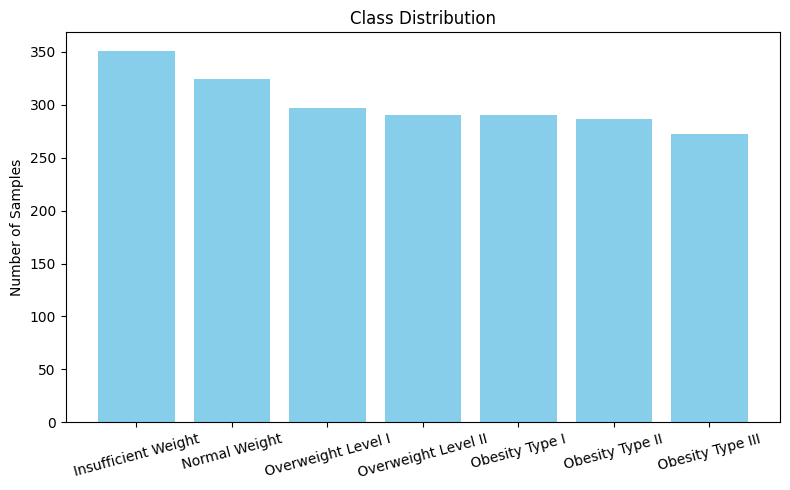

In [16]:
#Bar graph to show imbalance
import matplotlib.pyplot as plt

counts = np.array(value_counts)
classes = ['Insufficient Weight', 'Normal Weight', 'Overweight Level I', 'Overweight Level II', 'Obesity Type I', 'Obesity Type II','Obesity Type III']

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Value counts show mostly equal distribution because Balancing class was performed using the SMOTE filter using the tool Weka by previous researchers

Visualising categoricals by using plt.subplots() to plot multiple bargraphs in the same window

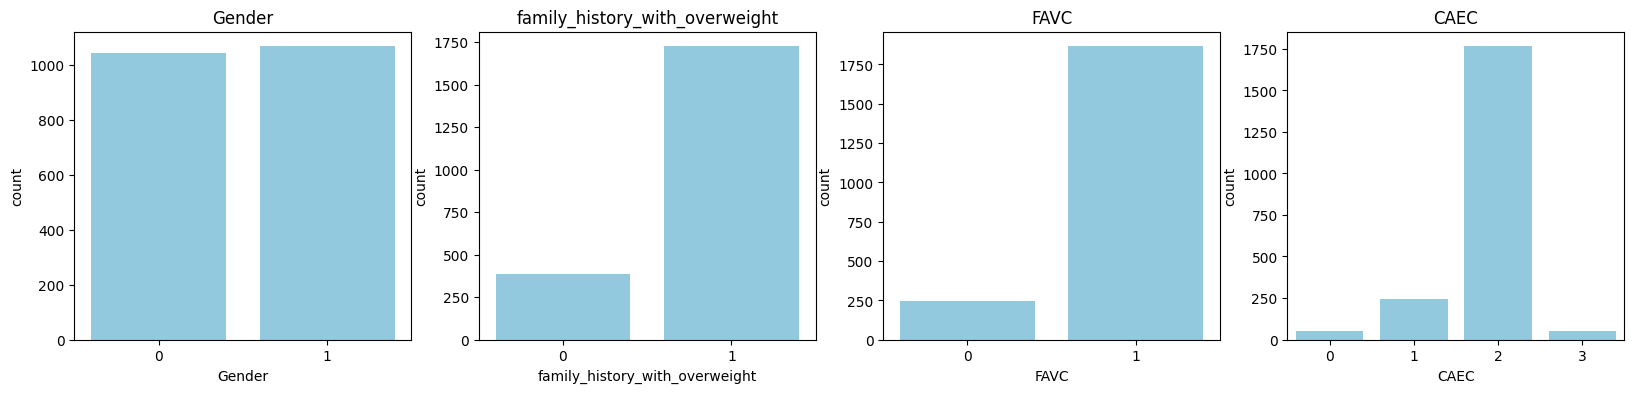

In [17]:
import seaborn as sns 

cols = ['Gender', 'family_history_with_overweight', 'FAVC','CAEC']
numerical = cols

plt.figure(figsize=(20,4))

for i, col in enumerate(numerical):
    ax = plt.subplot(1, len(numerical), i+1)
    sns.countplot(x=str(col), data=final_df, color='skyblue')
    ax.set_title(f"{col}")

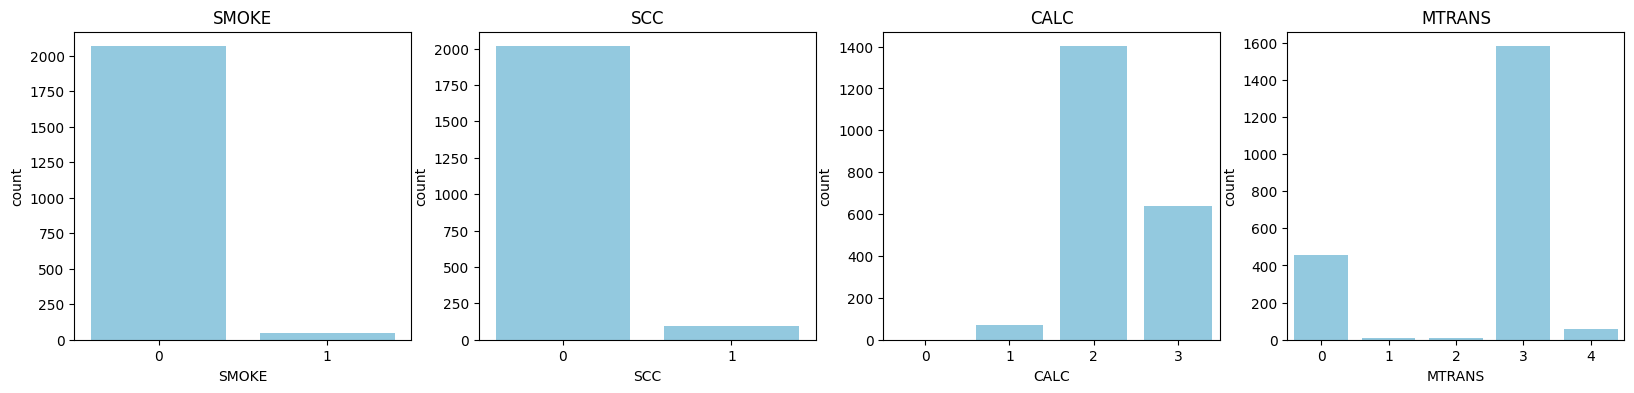

In [18]:
cols_2=['SMOKE','SCC', 'CALC', 'MTRANS']
numerical = cols_2

plt.figure(figsize=(20,4))

for i, col in enumerate(numerical):
    ax = plt.subplot(1, len(numerical), i+1)
    sns.countplot(x=str(col), data=final_df, color='skyblue')
    ax.set_title(f"{col}")

From this, it is apparent Gender and NObeyesdad are indeed equally distributed

Plot continuous variables and find distributions

In [19]:
num_cols = ['Age', 'Height', 'Weight','FCVC','NCP','CH2O','FAF','TUE']

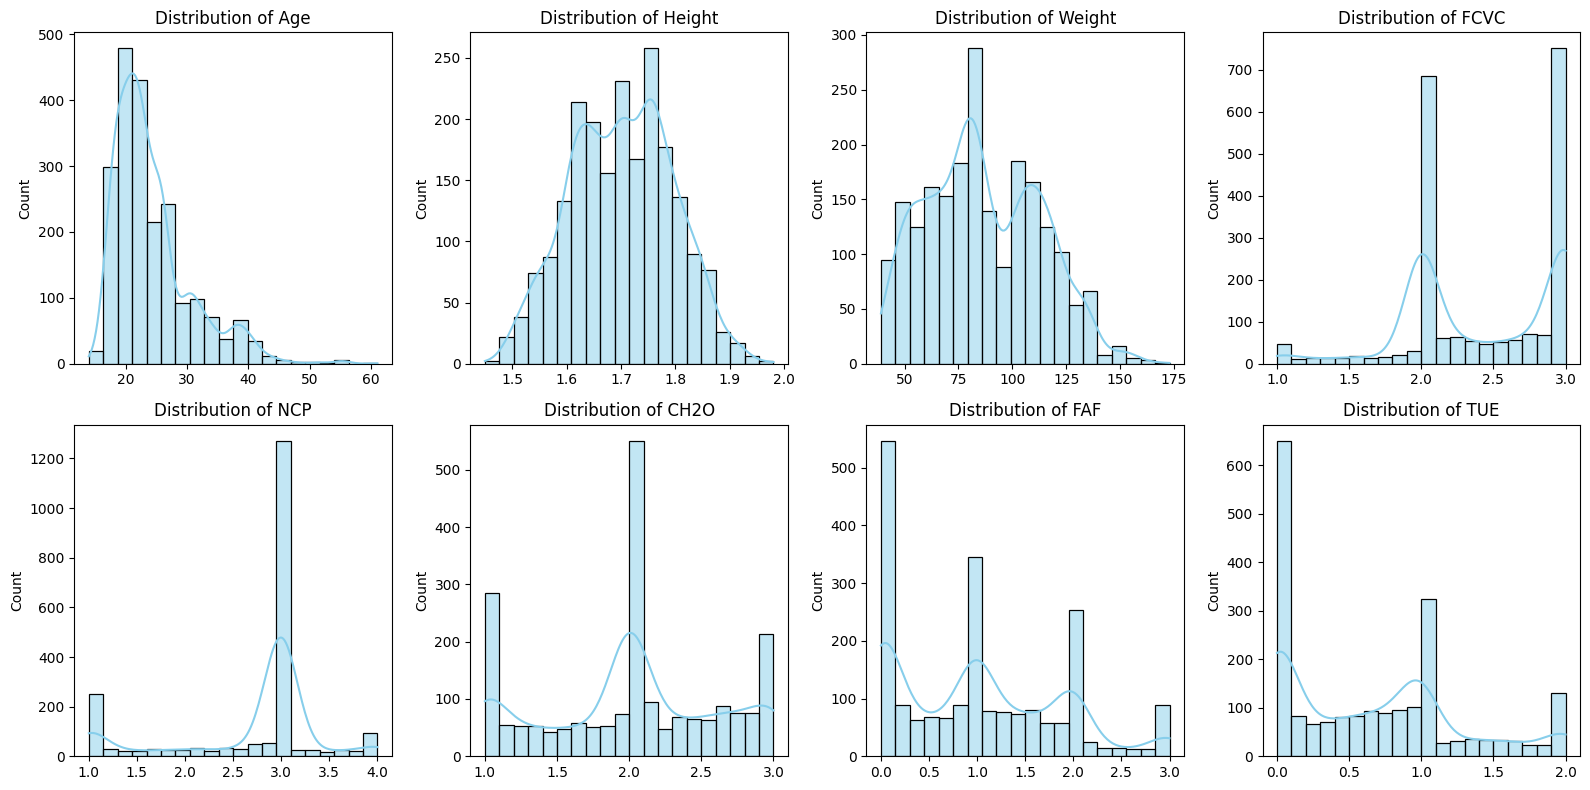

In [20]:
data = final_df

# 2. Setup Subplots (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()  # Flatten 2D array of axes to 1D for easy iteration

# 3. Plot Histograms
for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue', bins=20)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')  # Remove individual x-labels for cleaner look
    axes[i].set_ylabel('Count')

# 4. Finalize Layout
plt.tight_layout()
plt.show()


Finding: Height and weight are normally distributed. Age is positively skewed.

Further investigation of normality using Q-Q plots to check if features are distributed around the regression line

In [21]:
import statsmodels.api as sm

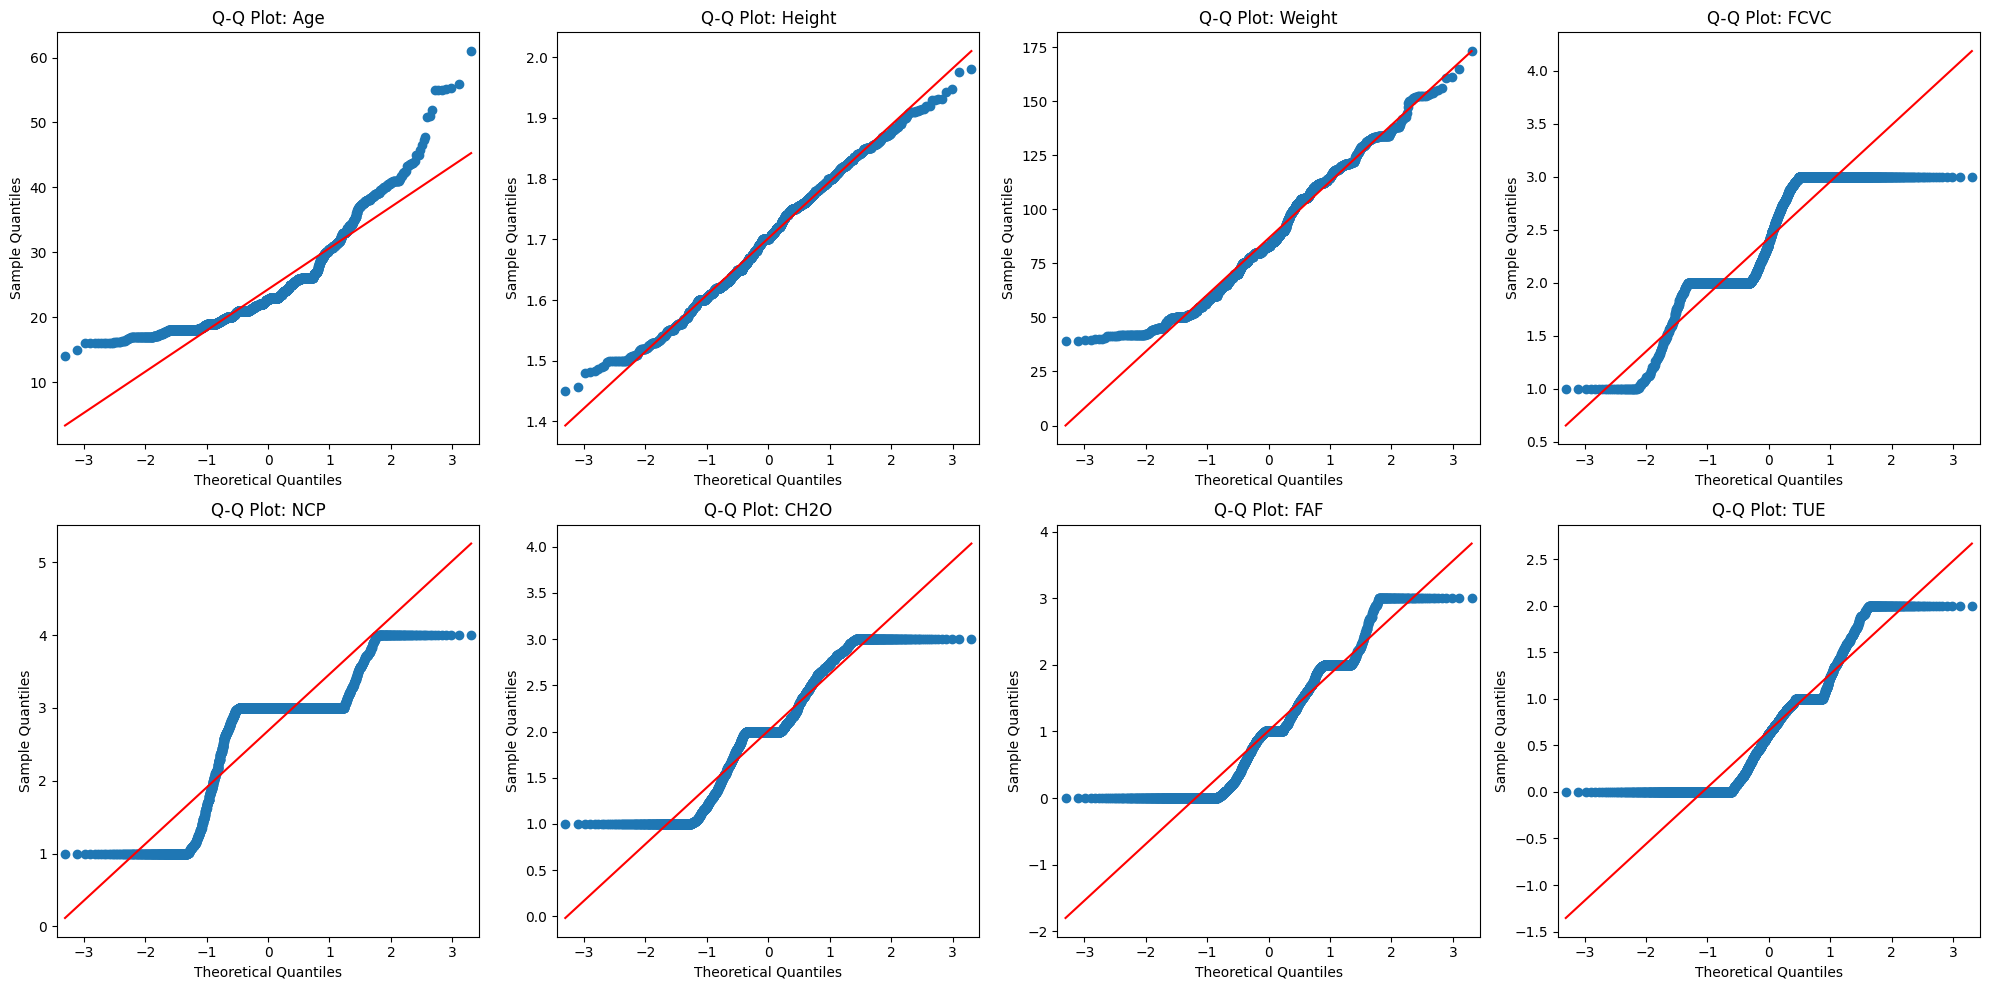

In [22]:
# Sample data creation (replace with actual DataFrame df)
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df = final_df

# Create 2x4 grid (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten 2D array to 1D for easy iteration

for i, col in enumerate(num_cols):
    # Plot Q-Q plot on the i-th axis
    sm.qqplot(df[col], line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()  # Prevents overlapping [3]
plt.show()


In light of these results features should be log-transformed and/or non-parametric tests should be used when features are analysed.However, I went ahead and used numerical skewness.

In [23]:
from scipy.stats import skew, kurtosis

In [24]:
# Calculate skewness
skewness_value = skew(num_features)
print(f"Skewness: {skewness_value}")

# Calculate kurtosis (excess kurtosis by default)
kurtosis_value = kurtosis(num_features)
print(f"Kurtosis (Excess): {kurtosis_value}")

Skewness: [ 1.52801362 -0.01284551  0.25522897 -0.43259816 -1.10631045 -0.10483708
  0.49813534  0.61806284]
Kurtosis (Excess): [ 2.81685813 -0.56445732 -0.70108242 -0.63887776  0.38177318 -0.88015401
 -0.62195975 -0.55020264]


In [25]:
# Example DataFrame
data = num_features

# Calculate skewness for all numerical columns
skewness_values = data.skew(numeric_only=True)
print("Skewness for each numerical column:")
print(skewness_values)

# Calculate kurtosis for all numerical columns
kurtosis_values = data.kurt(numeric_only=True)
print("\nKurtosis for each numerical column:")
print(kurtosis_values)

#normally distributed variables will have a skewness value 
# within the -0.8; 0.8 range and a kurtosis value within the -3.0; 3.0 range.

Skewness for each numerical column:
Age       1.529100
Height   -0.012855
Weight    0.255410
FCVC     -0.432906
NCP      -1.107097
CH2O     -0.104912
FAF       0.498490
TUE       0.618502
dtype: float64

Kurtosis for each numerical column:
Age       2.826389
Height   -0.562949
Weight   -0.699898
FCVC     -0.637546
NCP       0.385527
CH2O     -0.879395
FAF      -0.620588
TUE      -0.548660
dtype: float64


Numerical skewness found the following are skew:
* Age
*  NCP
*  CH2O

Kurtosis identified:
* Age
* Height
* Weight
* FCVC
* CH2O
* FAF
* TUE

Therefore, the follwowing are log_transformable: Age, FCVC, NCP, CH2O, FAF, and TUE

Decision: Unlike linear regression, NN and logistic regression does not strictly require the input features themselves to be normally distributed. The models used here are One V Rest Log and NN. NN and Logistic regression do not require log transforming.

# Feature Selection

Performing correlations using visualistions

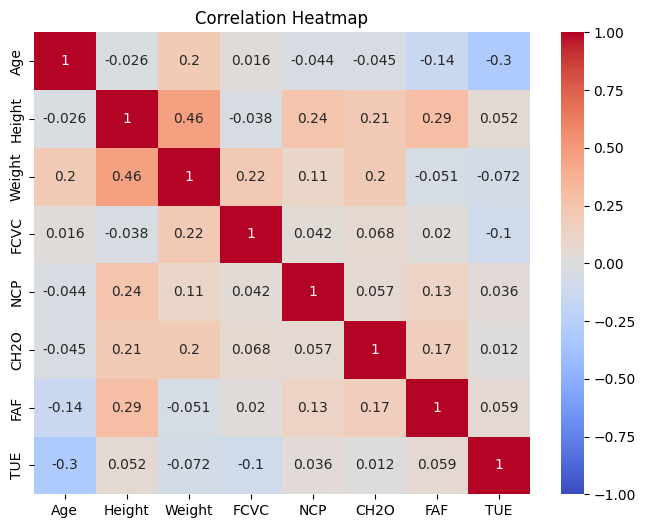

In [26]:
# Compute correlation matrix
corr_matrix = num_features.corr(numeric_only=True)

# Generate heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Correlation between 0.7 and 1 are considered high in medical research. Therefore, it appears there is no collinearity.

In [27]:
final_df

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,21.000000,1.620000,64.000000,2.0,3.0,2.000000,0.000000,1.000000,0,1,0,2,0,0,3,3,1
1,21.000000,1.520000,56.000000,3.0,3.0,3.000000,3.000000,0.000000,0,1,0,2,1,1,2,3,1
2,23.000000,1.800000,77.000000,2.0,3.0,2.000000,2.000000,1.000000,1,1,0,2,0,0,1,3,1
3,27.000000,1.800000,87.000000,3.0,3.0,2.000000,2.000000,0.000000,1,0,0,2,0,0,1,4,5
4,22.000000,1.780000,89.800000,2.0,1.0,2.000000,0.000000,0.000000,1,0,0,2,0,0,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,3.0,3.0,1.728139,1.676269,0.906247,0,1,1,2,0,0,2,3,4
2107,21.982942,1.748584,133.742943,3.0,3.0,2.005130,1.341390,0.599270,0,1,1,2,0,0,2,3,4
2108,22.524036,1.752206,133.689352,3.0,3.0,2.054193,1.414209,0.646288,0,1,1,2,0,0,2,3,4
2109,24.361936,1.739450,133.346641,3.0,3.0,2.852339,1.139107,0.586035,0,1,1,2,0,0,2,3,4


The final dataframe appears intact

# Test-Train Split

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'  # keep other columns unchanged
)

final_df_scaled = preprocessor.fit_transform(final_df)

In [29]:
import pandas as pd

final_df_scaled = pd.DataFrame(
    final_df_scaled,
    columns=num_cols + [c for c in final_df.columns if c not in num_cols]
)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# Separate features (X) and target variable (y)
X = final_df_scaled.drop(["NObeyesdad"], axis=1)
y = final_df_scaled["NObeyesdad"]

In [32]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

#The dataset is split into training and testing sets, with 30% of the data reserved for testing and 70% for training, 
# while random_state=42 ensures the split is reproducible each time the code is executed.

# Model Training

# One vs Rest Base Non-Tuned Model

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [34]:
logistic_model = LogisticRegression(solver='lbfgs', random_state=42)

In [35]:
ovr_wrapper_model = OneVsRestClassifier(logistic_model)

In [36]:
ovr_wrapper_model.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [37]:
class_labels = ovr_wrapper_model.classes_
print(f"Classes: {class_labels}")

Classes: [0. 1. 2. 3. 4. 5. 6.]


# Evaluation: One vs Rest Base Non-Tuned Model

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
predictions = ovr_wrapper_model.predict(X_test)

In [40]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93        82
         1.0       0.68      0.55      0.61        86
         2.0       0.63      0.70      0.66       106
         3.0       0.83      0.98      0.90        89
         4.0       1.00      0.99      0.99        97
         5.0       0.63      0.60      0.62        87
         6.0       0.55      0.47      0.51        87

    accuracy                           0.75       634
   macro avg       0.74      0.75      0.74       634
weighted avg       0.74      0.75      0.75       634



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

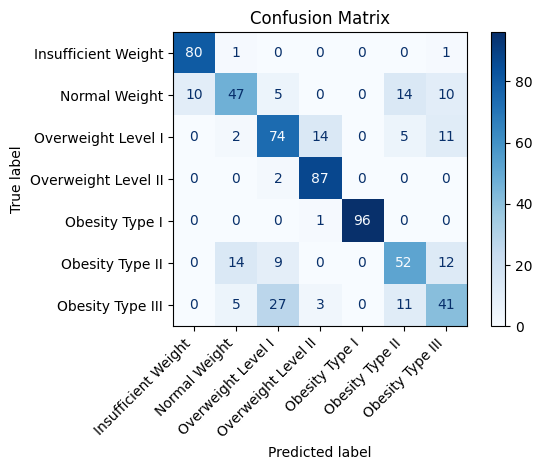

In [42]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, predictions)

# 2. Visualize the confusion matrix with labels
# Use ConfusionMatrixDisplay for an easy-to-read plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                                                                   "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                                                                   "Obesity Type III"])

# Plot the figure
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

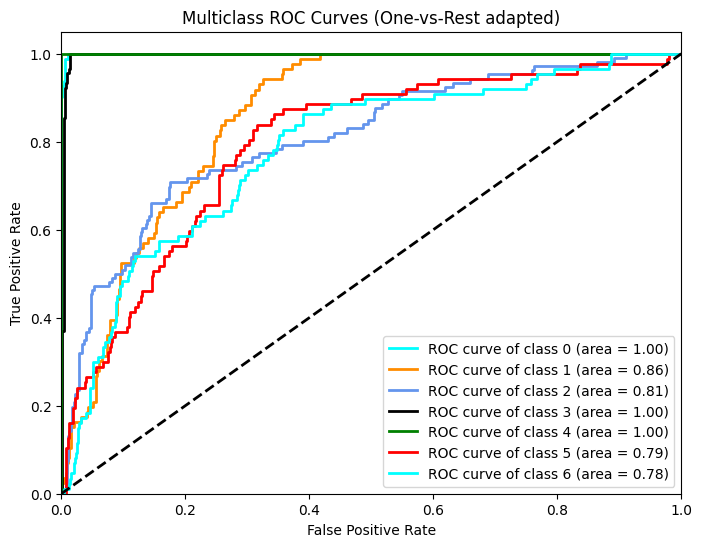

In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Note: The base estimator must support 'predict_proba' or 'decision_function'
# LinearSVC does not support predict_proba by default. We can use an SVC with probability=True
# or another classifier like Logistic Regression.
# This example uses a base Logistic Regression for probability outputs.

# Binarize the output labels for ROC curve plotting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5, 6])
n_classes = y_test_bin.shape[1]

y_score = ovr_wrapper_model.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'black', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest adapted)')
plt.legend(loc="lower right")
plt.show()

# Sequential Neural Network Base Model

In [44]:
print("X_train shape:", X_train.shape)

X_train shape: (1477, 16)


We use a deep learning model built with Keras, a high-level API for TensorFlow, to perform multiclass classification on the Palmer Penguins dataset. The model is a Sequential neural network, structured to learn from data and make accurate predictions based on input features.

•	✔ More capacity → learns complex feature interactions
•	✔ Dropout prevents overfitting despite size
•	✔ Depth is still reasonable (3 hidden layers)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
NN_model = Sequential([Input(shape=(16,)),

    Dense(128, activation='relu'),
    Dropout(0.25),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='softmax')
])

In [47]:
NN_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

NN_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1813 - loss: 1.9811 - val_accuracy: 0.3378 - val_loss: 1.7942
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2995 - loss: 1.7887 - val_accuracy: 0.4257 - val_loss: 1.6679
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 1.6419 - val_accuracy: 0.4797 - val_loss: 1.5403
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4327 - loss: 1.5346 - val_accuracy: 0.5270 - val_loss: 1.4066
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4868 - loss: 1.4018 - val_accuracy: 0.5608 - val_loss: 1.2673
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5395 - loss: 1.2697 - val_accuracy: 0.5608 - val_loss: 1.1583
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5546 - loss: 1.1716 - val_accuracy: 0.5878 - val_loss: 1.0665
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5877 - loss: 1.0793 - val_accuracy: 0.6689 - val_loss

# Evluation: Base NN model

In [48]:
NN_predictions = NN_model.predict(X_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [49]:
# 2. Convert probabilities to class labels
predicted_labels_NN = np.argmax(NN_predictions, axis=1)

In [50]:
NN_labels = [0, 1, 2, 3, 4, 5, 6]

print(classification_report(
    y_test,
    predicted_labels_NN,
    labels=NN_labels,
    target_names=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                  "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                  "Obesity Type III"]
))

                     precision    recall  f1-score   support

Insufficient Weight       0.69      0.93      0.79        82
      Normal Weight       0.50      0.47      0.48        86
 Overweight Level I       0.77      0.79      0.78       106
Overweight Level II       0.84      0.97      0.90        89
     Obesity Type I       0.97      0.99      0.98        97
    Obesity Type II       0.59      0.47      0.52        87
   Obesity Type III       0.66      0.48      0.56        87

           accuracy                           0.73       634
          macro avg       0.72      0.73      0.72       634
       weighted avg       0.72      0.73      0.72       634



In [51]:
np.unique(y_test)
np.unique(predicted_labels_NN)

array([0, 1, 2, 3, 4, 5, 6])

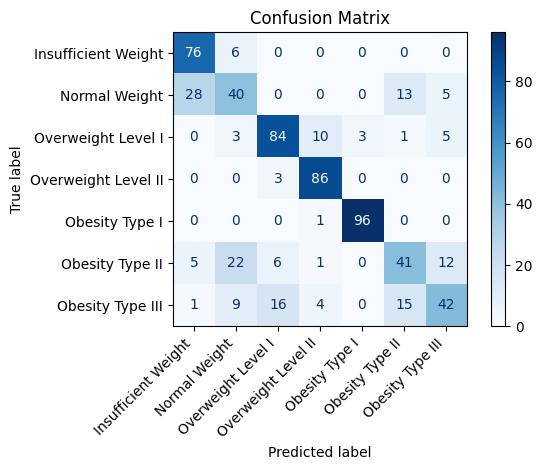

In [52]:
class_names = ["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                  "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                  "Obesity Type III"]

cm = confusion_matrix(y_test, predicted_labels_NN, labels=NN_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                                                                   "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                                                                   "Obesity Type III"])

# Plot the figure
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

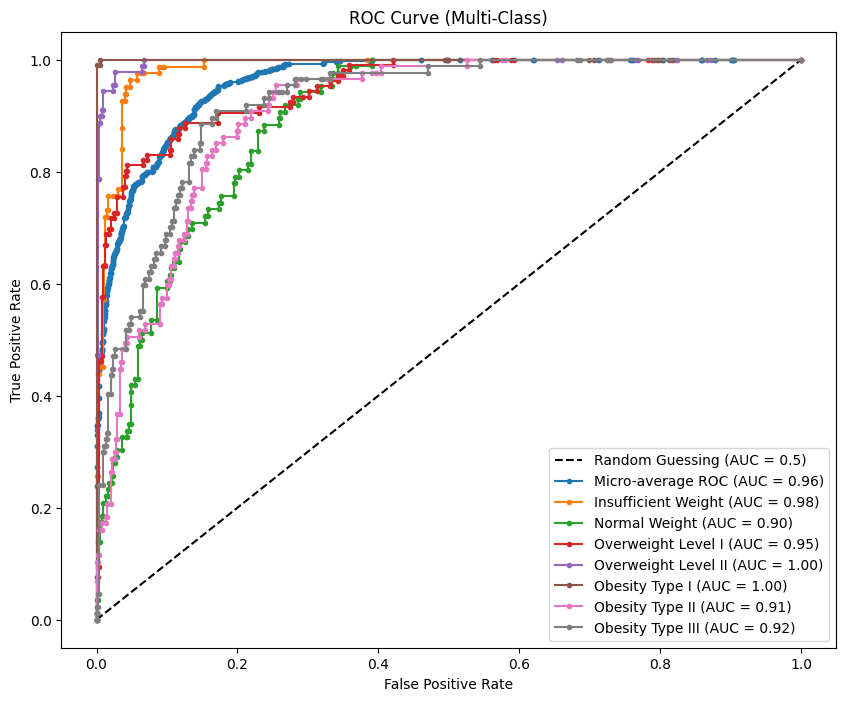

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc

# y_test contains the true class labels and you have class names
n_classes = len(class_names)

# Convert y_test to binary format
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Initialize lists to store ROC values
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], NN_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), NN_predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# Plot ROC Curve
plt.figure(figsize=(10, 8))

# Plot random guessing line (diagonal line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')

# Plot micro-average ROC
plt.plot(fpr["micro"], tpr["micro"], marker='.', label='Micro-average ROC (AUC = {:.2f})'.format(roc_auc["micro"]))

# Plot ROC for each class with custom labels
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], marker='.', label='{} (AUC = {:.2f})'.format(class_names[i], roc_auc[i]))

plt.title('ROC Curve (Multi-Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.show()

# Hyperparameter Tuning: OVR

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV

ovr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

param_grid = {
    'estimator__C': [0.01, 0.1, 1, 10, 100],
    'estimator__penalty': ['l2'],
    'estimator__solver': ['lbfgs']
}

grid = GridSearchCV(
    ovr,
    param_grid,
    cv=5,
    scoring='accuracy',  # or f1_macro
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,OneVsRestClas...ax_iter=1000))
,param_grid,"{'estimator__C': [0.01, 0.1, ...], 'estimator__penalty': ['l2'], 'estimator__solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [55]:
best_ovr_model = grid.best_estimator_

In [56]:
best_ovr_model.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


# Evaluation: One vs Rest Tuned Model

In [57]:
class_labels = best_ovr_model.classes_
print(f"Classes: {class_labels}")

Classes: [0. 1. 2. 3. 4. 5. 6.]


In [58]:
tuned_ovr_predictions = best_ovr_model.predict(X_test)

In [59]:
print("Classification Report:")
print(classification_report(y_test, tuned_ovr_predictions))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99        82
         1.0       0.70      0.60      0.65        86
         2.0       0.65      0.75      0.70       106
         3.0       0.91      0.97      0.94        89
         4.0       1.00      0.99      0.99        97
         5.0       0.62      0.61      0.61        87
         6.0       0.53      0.48      0.50        87

    accuracy                           0.77       634
   macro avg       0.77      0.77      0.77       634
weighted avg       0.77      0.77      0.77       634



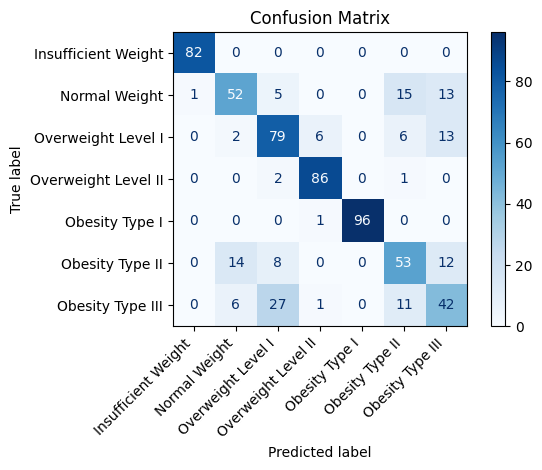

In [60]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, tuned_ovr_predictions)

# 2. Visualize the confusion matrix with labels
# Use ConfusionMatrixDisplay for an easy-to-read plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                                                                   "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                                                                   "Obesity Type III"])

# Plot the figure
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

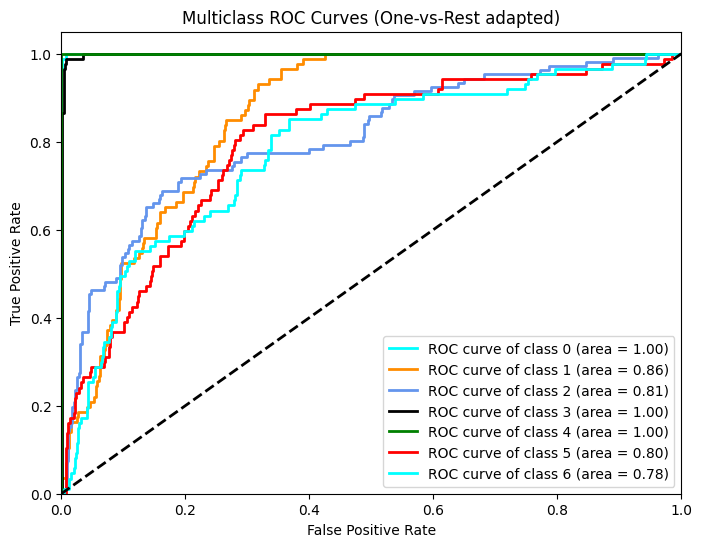

In [61]:
# Binarize the output labels for ROC curve plotting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5, 6])
n_classes = y_test_bin.shape[1]

y_score = best_ovr_model.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'black', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest adapted)')
plt.legend(loc="lower right")
plt.show()

# Explaining individual models within OVR

In [62]:
# Get the list of individual fitted models
individual_models = best_ovr_model.estimators_

# Get the class labels corresponding to the models
class_labels = best_ovr_model.classes_


In [63]:
print("Classes:", class_labels)
print("Number of estimators:", len(individual_models))

Classes: [0. 1. 2. 3. 4. 5. 6.]
Number of estimators: 7


In [64]:
coefs = []
for i, estimator in enumerate(individual_models):
    # Coefficients are stored in the coef_ attribute
    class_coef = pd.Series(estimator.coef_[0], index=X_train.columns)
    coefs.append(class_coef)

In [65]:
# Create a final DataFrame with feature names as rows and class labels as columns
coefs_df = pd.DataFrame(coefs).transpose()
coefs_df.columns = [f'Class_{c}_coef' for c in class_labels]
sorted_coefs_df = sorted(coefs_df.columns, reverse=True)

print("\nCoefficients with feature names with coefficients sorted from largest to smallest:")
print(sorted_coefs_df)


Coefficients with feature names with coefficients sorted from largest to smallest:
['Class_6.0_coef', 'Class_5.0_coef', 'Class_4.0_coef', 'Class_3.0_coef', 'Class_2.0_coef', 'Class_1.0_coef', 'Class_0.0_coef']


In [66]:
print("Individual One-vs-Rest Logistic Regression Models:")
for i, model in enumerate(individual_models):
    print(f"\n--- Model for class: {class_labels[i]} (vs all others) ---")
    print(f"  Intercept: {model.intercept_}")
    print(f"  Coefficients: {model.coef_}")

Individual One-vs-Rest Logistic Regression Models:

--- Model for class: 0.0 (vs all others) ---
  Intercept: [-47.32749818]
  Coefficients: [[-3.50149796e-01  8.09235061e+00 -3.99171173e+01  4.19630438e-01
   3.85826283e-01  4.94088475e-01  3.92428526e-02 -2.19525539e-02
  -1.63527485e-02  3.09656758e-01 -8.26633669e-02 -6.84694176e-01
  -6.84366580e-01 -7.04761537e-01 -3.56301104e-01 -2.49914208e-01]]

--- Model for class: 1.0 (vs all others) ---
  Intercept: [-0.86054881]
  Coefficients: [[-0.00258898 -0.0994884  -1.64412619 -0.16708908  0.02533473 -0.21196069
   0.29685312 -0.13249419  1.3258937  -0.16890526 -0.46645517 -0.87095011
   0.959701    0.16571248 -0.30835417  0.03800208]]

--- Model for class: 2.0 (vs all others) ---
  Intercept: [-8.33785487]
  Coefficients: [[-0.24651583 -0.78089147  0.8736762  -0.84891652 -0.45814851  0.32822845
   0.20368376  0.08583795  0.2139272   2.66416857  2.58458883  0.13597052
   0.67653817 -2.40891537  0.8109205  -0.35412399]]

--- Model for 

# Hyperparameter Tuning: Sequential Neural Network

In [67]:
import tensorflow as tf

tuned_model_NN = Sequential([
    Input(shape=(16,)),

    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.3),

    Dense(32, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),

    Dense(7, activation='softmax')
])

tuned_model_NN.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [68]:
def build_model(hp):
    model = Sequential([
        Input(shape=(16,)),
        Dense(hp.Int('units1', 32, 128, step=32), activation='relu'),
        Dropout(hp.Float('dropout1', 0.2, 0.4, step=0.1)),
        Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice('lr', [1e-2, 1e-3, 3e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [69]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,          # enough for large dataset
    executions_per_trial=1,
    directory='obesity',
    project_name='best_NN_for_obesity'
)

Reloading Tuner from obesity/best_NN_for_obesity/tuner0.json


In [70]:
tuner.search(
    X_train,
    y_train,
    epochs=15,              # short for tuning
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

In [71]:
best_hp = tuner.get_best_hyperparameters(1)[0]

In [72]:
from tensorflow import keras

best_model = tuner.get_best_models(1)[0]

history = best_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/10


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8348 - loss: 0.4145 - val_accuracy: 0.9038 - val_loss: 0.3105
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8747 - loss: 0.3543 - val_accuracy: 0.9196 - val_loss: 0.2682
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8666 - loss: 0.3280 - val_accuracy: 0.9180 - val_loss: 0.2480
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8842 - loss: 0.3033 - val_accuracy: 0.9180 - val_loss: 0.2400
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8984 - loss: 0.2788 - val_accuracy: 0.8991 - val_loss: 0.2376
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8910 - loss: 0.2936 - val_accuracy: 0.9101 - val_loss: 0.2264
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8896 - loss: 0.2861 - val_accuracy: 0.9117 - val_loss: 0.2244
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8984 - loss: 0.2665 - val_accuracy: 0.9290 - val_loss: 0.2002
Epo

In [73]:
# Display Model Summary
print("Model Summary:")
best_model.summary()

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,631 (18.09 KB)

 Trainable params: 1,543 (6.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,088 (12.07 KB)

# Evaluation: Sequential Neural Network Tuned Model

In [74]:
# 6. Evaluate the model
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 0.19125622510910034
Test Accuracy: 0.92586749792099


In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

In [76]:
# 1. Make predictions
tuned_predictions = best_model.predict(X_test)
tuned_predictions.shape

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


(634, 7)

In [77]:
# 2. Convert probabilities to class labels
predicted_labels = np.argmax(tuned_predictions, axis=1)
predicted_labels.shape

(634,)

In [78]:
print(classification_report(
    y_test,
    predicted_labels,
    labels=NN_labels,
    target_names=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                  "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                  "Obesity Type III"]
))

                     precision    recall  f1-score   support

Insufficient Weight       0.92      0.99      0.95        82
      Normal Weight       0.85      0.84      0.84        86
 Overweight Level I       0.99      0.91      0.95       106
Overweight Level II       0.98      0.99      0.98        89
     Obesity Type I       1.00      0.99      0.99        97
    Obesity Type II       0.88      0.80      0.84        87
   Obesity Type III       0.86      0.97      0.91        87

           accuracy                           0.93       634
          macro avg       0.92      0.93      0.92       634
       weighted avg       0.93      0.93      0.93       634



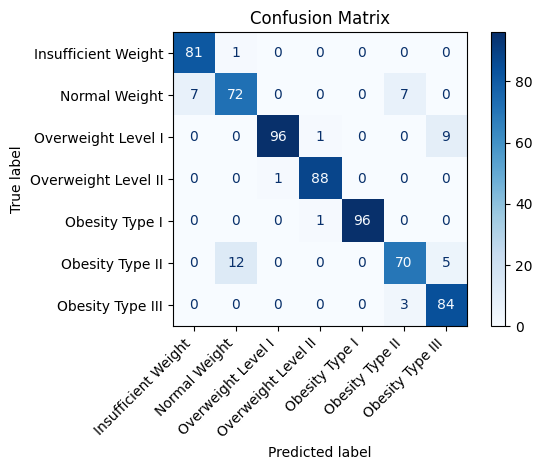

In [79]:
class_names = ["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                  "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                  "Obesity Type III"]

cm = confusion_matrix(y_test, predicted_labels, labels=NN_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Insufficient Weight", "Normal Weight", "Overweight Level I", 
                                                                   "Overweight Level II", "Obesity Type I", "Obesity Type II", 
                                                                   "Obesity Type III"])

# Plot the figure
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

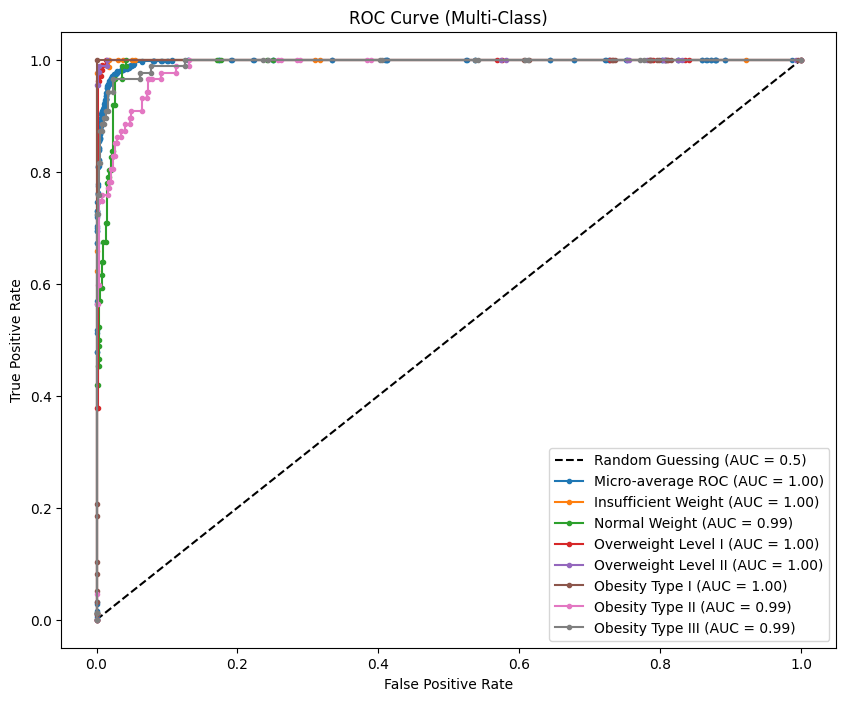

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc

# y_test contains the true class labels and you have class names
n_classes = len(class_names)

# Convert y_test to binary format
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Initialize lists to store ROC values
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], tuned_predictions[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), tuned_predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# Plot ROC Curve
plt.figure(figsize=(10, 8))

# Plot random guessing line (diagonal line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')

# Plot micro-average ROC
plt.plot(fpr["micro"], tpr["micro"], marker='.', label='Micro-average ROC (AUC = {:.2f})'.format(roc_auc["micro"]))

# Plot ROC for each class with custom labels
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], marker='.', label='{} (AUC = {:.2f})'.format(class_names[i], roc_auc[i]))

plt.title('ROC Curve (Multi-Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.show()

# Explaining

In [81]:
import shap

background_data = shap.sample(X_train, 100)
explainer = shap.KernelExplainer(best_model.predict, background_data)
X_explain = shap.sample(X_test, 100)
shap_values = explainer(X_explain)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                   | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 212us/step


  1%|▍                                          | 1/100 [00:02<03:44,  2.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 214us/step


  2%|▊                                          | 2/100 [00:04<03:29,  2.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 213us/step


  3%|█▎                                         | 3/100 [00:06<03:23,  2.10s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 208us/step


  4%|█▋                                         | 4/100 [00:08<03:17,  2.06s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 203us/step


  5%|██▏                                        | 5/100 [00:10<03:12,  2.02s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 217us/step


  6%|██▌                                        | 6/100 [00:12<03:10,  2.03s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 199us/step


  7%|███                                        | 7/100 [00:14<03:05,  2.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 229us/step


  8%|███▍                                       | 8/100 [00:16<03:07,  2.04s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 198us/step


  9%|███▊                                       | 9/100 [00:18<03:02,  2.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 200us/step


 10%|████▏                                     | 10/100 [00:20<02:59,  2.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 204us/step


 11%|████▌                                     | 11/100 [00:22<02:56,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 222us/step


 12%|█████                                     | 12/100 [00:24<02:56,  2.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 220us/step


 13%|█████▍                                    | 13/100 [00:26<02:57,  2.04s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 210us/step


 14%|█████▉                                    | 14/100 [00:28<02:54,  2.03s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 209us/step


 15%|██████▎                                   | 15/100 [00:30<02:51,  2.02s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 193us/step


 16%|██████▋                                   | 16/100 [00:32<02:46,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 206us/step


 17%|███████▏                                  | 17/100 [00:34<02:43,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 202us/step


 18%|███████▌                                  | 18/100 [00:36<02:41,  1.97s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 222us/step


 19%|███████▉                                  | 19/100 [00:38<02:42,  2.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 20%|████████▍                                 | 20/100 [00:40<02:37,  1.97s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 206us/step


 21%|████████▊                                 | 21/100 [00:42<02:35,  1.97s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 201us/step


 22%|█████████▏                                | 22/100 [00:44<02:32,  1.96s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 198us/step


 23%|█████████▋                                | 23/100 [00:46<02:29,  1.95s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 225us/step


 24%|██████████                                | 24/100 [00:48<02:31,  2.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 2s 235us/step


 25%|██████████▌                               | 25/100 [00:50<02:34,  2.06s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 208us/step


 26%|██████████▉                               | 26/100 [00:52<02:32,  2.06s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 203us/step


 27%|███████████▎                              | 27/100 [00:54<02:28,  2.04s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 205us/step


 28%|███████████▊                              | 28/100 [00:56<02:24,  2.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 200us/step


 29%|████████████▏                             | 29/100 [00:58<02:20,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 30%|████████████▌                             | 30/100 [01:00<02:16,  1.95s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 31%|█████████████                             | 31/100 [01:02<02:13,  1.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 212us/step


 32%|█████████████▍                            | 32/100 [01:04<02:16,  2.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 215us/step


 33%|█████████████▊                            | 33/100 [01:06<02:14,  2.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 34%|██████████████▎                           | 34/100 [01:08<02:10,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 35%|██████████████▋                           | 35/100 [01:10<02:06,  1.95s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 36%|███████████████                           | 36/100 [01:11<02:03,  1.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 37%|███████████████▌                          | 37/100 [01:13<02:00,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 38%|███████████████▉                          | 38/100 [01:15<01:57,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 39%|████████████████▍                         | 39/100 [01:17<01:55,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 40%|████████████████▊                         | 40/100 [01:19<01:57,  1.96s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 41%|█████████████████▏                        | 41/100 [01:21<01:54,  1.94s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 42%|█████████████████▋                        | 42/100 [01:23<01:51,  1.92s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 43%|██████████████████                        | 43/100 [01:25<01:48,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 44%|██████████████████▍                       | 44/100 [01:27<01:46,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 45%|██████████████████▉                       | 45/100 [01:29<01:44,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 46%|███████████████████▎                      | 46/100 [01:30<01:42,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 47%|███████████████████▋                      | 47/100 [01:32<01:40,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 48%|████████████████████▏                     | 48/100 [01:34<01:38,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 192us/step


 49%|████████████████████▌                     | 49/100 [01:36<01:35,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 50%|█████████████████████                     | 50/100 [01:38<01:33,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 51%|█████████████████████▍                    | 51/100 [01:40<01:32,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 200us/step


 52%|█████████████████████▊                    | 52/100 [01:42<01:30,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 53%|██████████████████████▎                   | 53/100 [01:44<01:28,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 54%|██████████████████████▋                   | 54/100 [01:46<01:26,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 55%|███████████████████████                   | 55/100 [01:47<01:24,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 211us/step


 56%|███████████████████████▌                  | 56/100 [01:49<01:24,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 193us/step


 57%|███████████████████████▉                  | 57/100 [01:51<01:21,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 58%|████████████████████████▎                 | 58/100 [01:53<01:19,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 59%|████████████████████████▊                 | 59/100 [01:55<01:17,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 60%|█████████████████████████▏                | 60/100 [01:57<01:15,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 61%|█████████████████████████▌                | 61/100 [01:59<01:13,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 62%|██████████████████████████                | 62/100 [02:01<01:11,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 63%|██████████████████████████▍               | 63/100 [02:03<01:09,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 64%|██████████████████████████▉               | 64/100 [02:04<01:07,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step


 65%|███████████████████████████▎              | 65/100 [02:06<01:05,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 192us/step


 66%|███████████████████████████▋              | 66/100 [02:08<01:03,  1.87s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 67%|████████████████████████████▏             | 67/100 [02:10<01:01,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 68%|████████████████████████████▌             | 68/100 [02:12<01:00,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 208us/step


 69%|████████████████████████████▉             | 69/100 [02:14<00:59,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 70%|█████████████████████████████▍            | 70/100 [02:16<00:57,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 71%|█████████████████████████████▊            | 71/100 [02:18<00:54,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 201us/step


 72%|██████████████████████████████▏           | 72/100 [02:20<00:53,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 214us/step


 73%|██████████████████████████████▋           | 73/100 [02:22<00:52,  1.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 192us/step


 74%|███████████████████████████████           | 74/100 [02:23<00:49,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 75%|███████████████████████████████▌          | 75/100 [02:25<00:47,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 76%|███████████████████████████████▉          | 76/100 [02:27<00:45,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 77%|████████████████████████████████▎         | 77/100 [02:29<00:43,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 78%|████████████████████████████████▊         | 78/100 [02:31<00:41,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 79%|█████████████████████████████████▏        | 79/100 [02:33<00:39,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 80%|█████████████████████████████████▌        | 80/100 [02:35<00:37,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 81%|██████████████████████████████████        | 81/100 [02:37<00:35,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 82%|██████████████████████████████████▍       | 82/100 [02:39<00:33,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 193us/step


 83%|██████████████████████████████████▊       | 83/100 [02:40<00:32,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 198us/step


 84%|███████████████████████████████████▎      | 84/100 [02:42<00:30,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 198us/step


 85%|███████████████████████████████████▋      | 85/100 [02:44<00:28,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 198us/step


 86%|████████████████████████████████████      | 86/100 [02:46<00:26,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 199us/step


 87%|████████████████████████████████████▌     | 87/100 [02:48<00:24,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 88%|████████████████████████████████████▉     | 88/100 [02:50<00:23,  1.92s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 89%|█████████████████████████████████████▍    | 89/100 [02:52<00:21,  1.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 90%|█████████████████████████████████████▊    | 90/100 [02:54<00:19,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 191us/step


 91%|██████████████████████████████████████▏   | 91/100 [02:56<00:16,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 92%|██████████████████████████████████████▋   | 92/100 [02:57<00:15,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 93%|███████████████████████████████████████   | 93/100 [02:59<00:13,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 94%|███████████████████████████████████████▍  | 94/100 [03:01<00:11,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 95%|███████████████████████████████████████▉  | 95/100 [03:03<00:09,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 96%|████████████████████████████████████████▎ | 96/100 [03:05<00:07,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 97%|████████████████████████████████████████▋ | 97/100 [03:07<00:05,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


 98%|█████████████████████████████████████████▏| 98/100 [03:09<00:03,  1.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step


 99%|█████████████████████████████████████████▌| 99/100 [03:11<00:01,  1.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 1s 197us/step


100%|█████████████████████████████████████████| 100/100 [03:13<00:00,  1.93s/it]


The beeswarm plot is designed to display an information-dense summary of how the top features in a dataset impact the model’s output. Each instance the given explanation is represented by a single dot on each feature row. 

In the visualisation, by default the features are ordered using shap_values.abs.mean(0), which is the mean absolute value of the SHAP values for each feature. This order places emphasis on broad average impact.

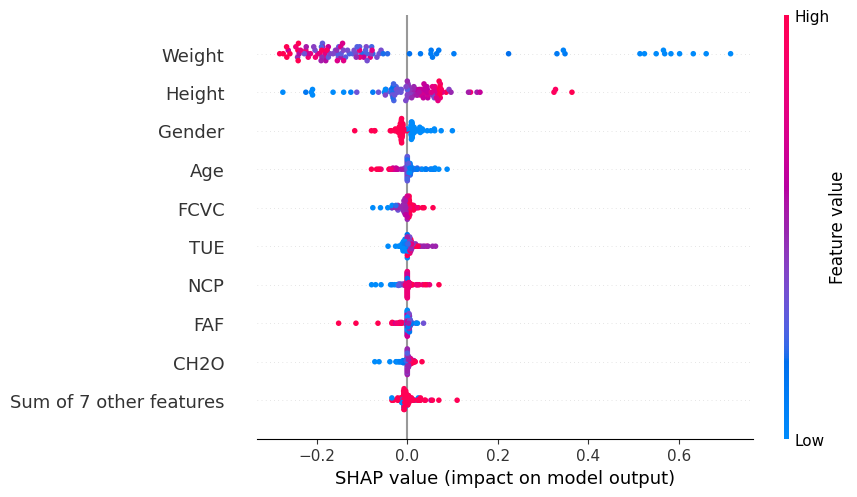

In [82]:
class_idx = 0  # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx])

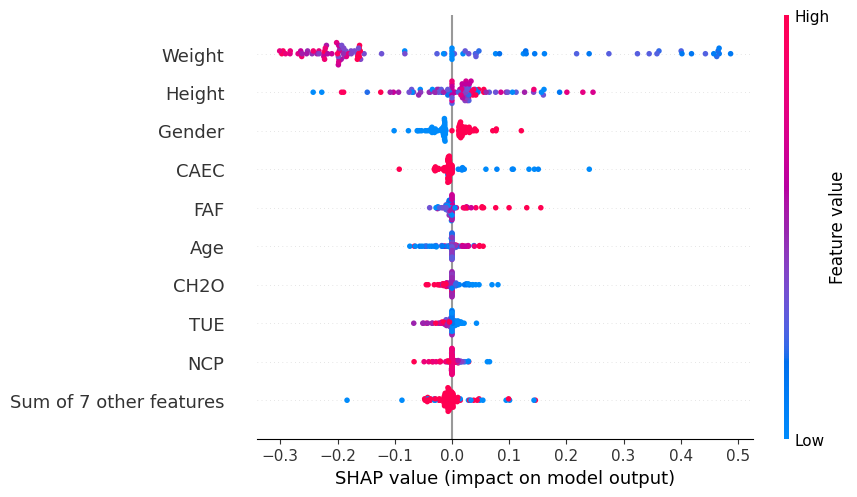

In [83]:
class_idx_1 = 1 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_1])

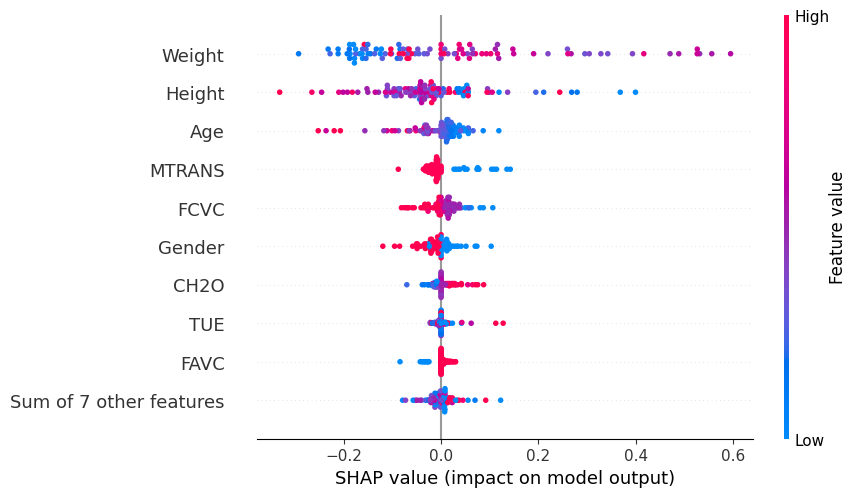

In [84]:
class_idx_2 = 2 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_2])

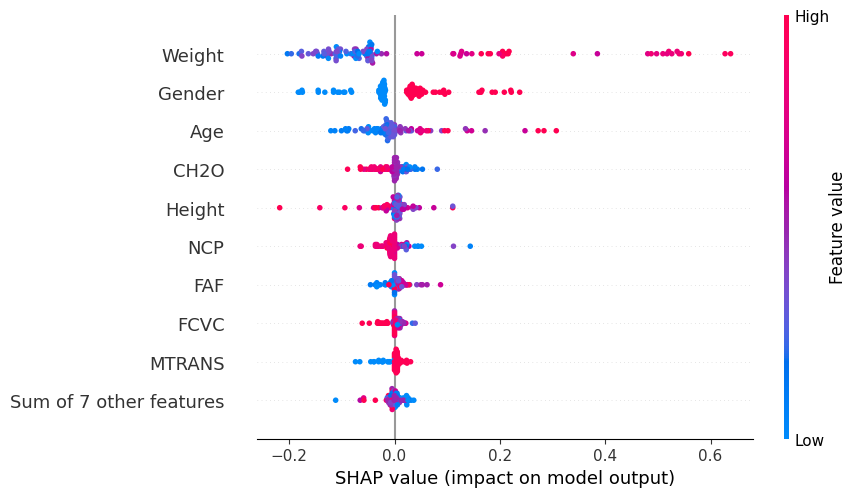

In [85]:
class_idx_3 = 3 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_3])

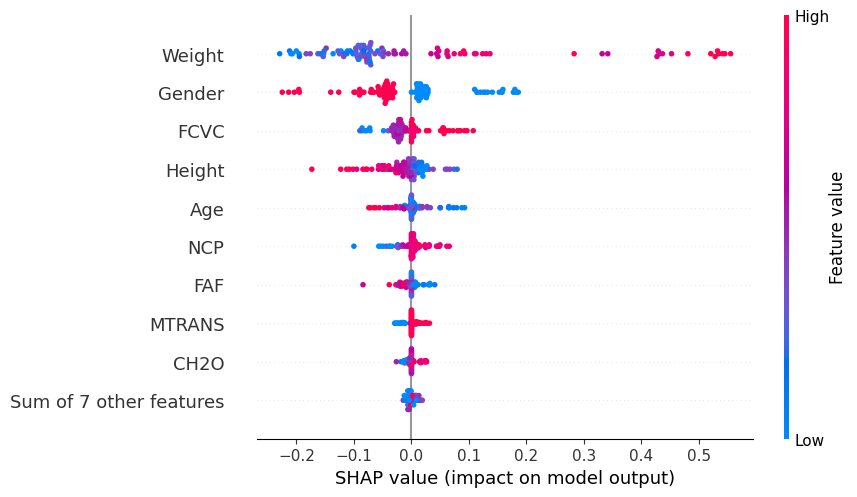

In [86]:
class_idx_4 = 4 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_4])

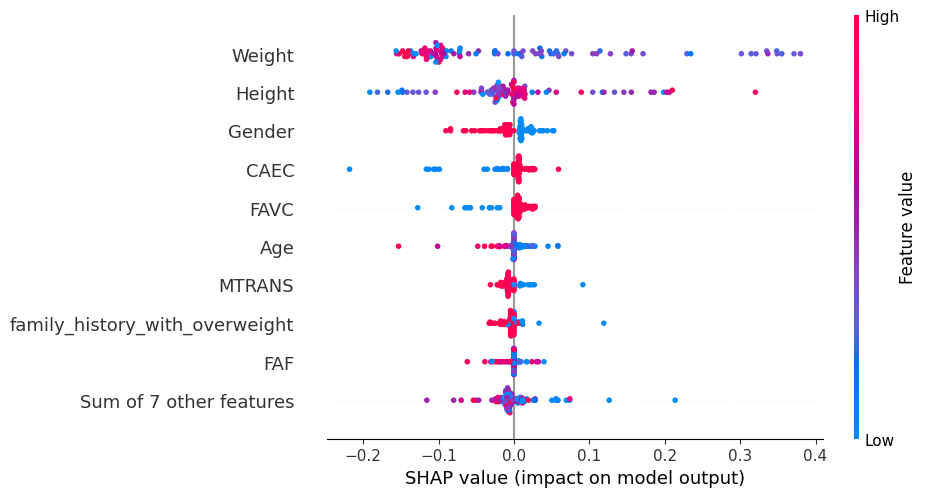

In [87]:
class_idx_5 = 5 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_5])

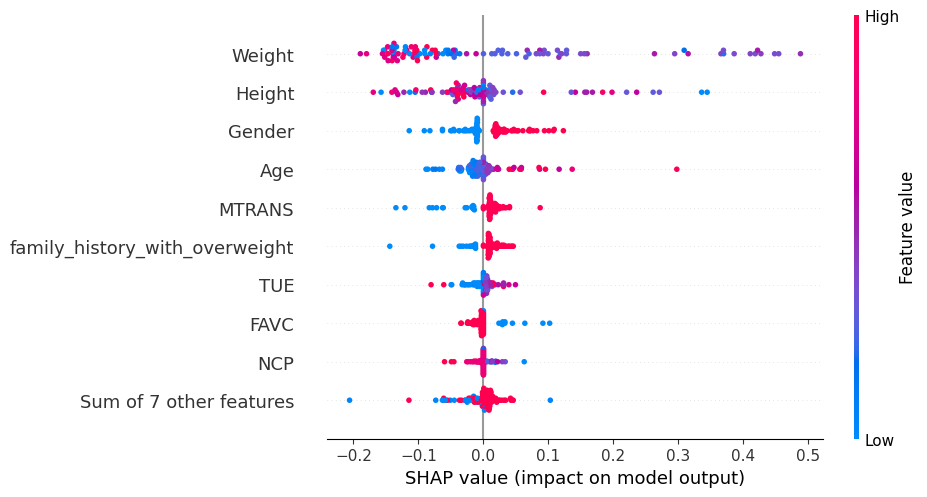

In [88]:
class_idx_6 = 6 # choose 0–6

shap.plots.beeswarm(shap_values[..., class_idx_6])

I used LASSO to see least informative features for the current predictions

In [90]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=17)
lasso.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,17
,selection,'cyclic'


In [91]:
lasso_coef = pd.DataFrame(
    {"coef": lasso.coef_, "coef_abs": np.abs(lasso.coef_)},
    index=df.columns.drop("NObeyesdad"),
)
lasso_coef.sort_values(by="coef_abs", ascending=False)

,coef,coef_abs
CAEC,0.900681,0.900681
family_history_with_overweight,0.748693,0.748693
FAVC,-0.565654,0.565654
Weight,0.525817,0.525817
Age,0.344243,0.344243
CALC,-0.339915,0.339915
SMOKE,-0.271264,0.271264
SCC,0.171589,0.171589
Height,-0.168661,0.168661
NCP,-0.165762,0.165762


# Conclusion: based on the tuned models, the NN is the better performer. Albeit, the NN is not as explainable.

# Saving the best model

In [92]:
import pickle

# Assume 'model' is your trained machine learning model
filename = '/Users/donavanrooi/Documents/Data Science/Obesity Level/finalized_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

In [93]:
# To load it later

In [94]:
'''
import pickle

filename = '/Users/donavanrooi/Documents/Data Science/Obesity Level/finalized_model.pkl'

with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

# You can now use the loaded_model for predictions
# predictions = loaded_model.predict(X_test)

SyntaxError: incomplete input (3528370751.py, line 1)